# Libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import pickle
import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d
import pandas as pd
import ast
import time
from collections import defaultdict
import time
from colossus.lss import peaks
from colossus.lss import bias
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18');
import MAS_library as MASL
import plotting_library as PL
from pylab import *
from matplotlib.colors import LogNorm
import matplotlib as plt
import pandas as pd
import h5py as h5
import matplotlib.pyplot as plt
from colossus.cosmology import cosmology
from colossus.lss import mass_function
import mass_function_library as MFL

In [2]:
pwd

'/mn/stornext/d14/gravity/personal/hassanif/projects/Neutrino_Niayesh/Analysis/Figs_post_processing'

# Loading Halo Catalogues

In [2]:
sim_spec_s= "L_1024_Ngrid_512/"
sim_spec_m= "L_1024_Ngrid_1024/"
sim="0.0ev"
sim_l="nu0meV"

halos_catalogue_small = np.loadtxt("./../../simulations/"+sim_spec_s+sim+"/output/halos/out_2.list");
halos_catalogue_medium =np.loadtxt("./../../simulations/"+sim_spec_m+"/simulations/"+sim+"/output/halos/out_2.list");
halos_catalogue_large = np.loadtxt("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat");


# HMF from Pylians and Clossus

In [3]:
import mass_function_library as MFL
##### Clossus
# M = 10**np.arange(11.0, 15.5, 0.1)
# mfunc = mass_function.massFunction(M, z[i], mdef = '200m', model = 'tinker08', q_out = 'dndlnM')

## Pylians
def nested_dict(n, type):
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
HMF = nested_dict(4, list)

M_min = 12.2
M_max = 16.1
num = 100

names = ['ST','Tinker','Tinker10']

class_lcdm =  np.loadtxt("./../class_runs//lcdm/output/file_z18_pk.dat")
Pk_lcdm = class_lcdm[:,1] #file with linear Pk
k_lcdm =  class_lcdm[:,0]
##
class_0d3 =  np.loadtxt("./../class_runs/0d3eV//output/file_z18_pk.dat")
Pk_0d3 = class_0d3[:,1] #file with linear Pk
k_0d3 =  class_0d3[:,0]

OmegaM = 0.3189
Masses = np.logspace(M_min, M_max, num) #array with halo masses
bins   = 10000  #number of bins to use for Pk
z      = 0.0    #redshift; only used for Tinker, Tinker10 and Crocce
delta  = 200.0  #overdensity; only for Tinker and Tinker10
# read linear matter Pk
# compute halo mass function
for author in names:
    HMF_data = MFL.MF_theory(k_lcdm, Pk_lcdm, OmegaM, Masses, author, bins, z, delta)
    HMF[author]['dNdlogM']['lcdm'] = HMF_data;
    
    HMF_data_0d3 = MFL.MF_theory(k_0d3, Pk_0d3, OmegaM, Masses, author, bins, z, delta)
    HMF[author]['dNdlogM']['nu0d3'] = HMF_data_0d3;

Delta= 200.0
A= 0.186
a= 1.47
b= 2.57
c= 1.19
Delta= 200.0
A= 0.186
a= 1.47
b= 2.57
c= 1.19


## Print the headers and each column

In [4]:
f = open("./../../simulations/"+sim_spec_s+sim+"/output/halos/out_2.list")
g = open("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat")

header = f.readline()
header_l = g.readline()

header_list = header.split(' ') #list of columns
header_list_l = header_l.split(' ') #list of columns

print(header_list)
print(header_list_l)
print(header_list.index("Mvir"))
for num in [0, 1, 2, 20]:
    print("Column: "+str(num)+ " is " + header_list[num])


['#ID', 'DescID', 'Mvir', 'Vmax', 'Vrms', 'Rvir', 'Rs', 'Np', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ', 'JX', 'JY', 'JZ', 'Spin', 'rs_klypin', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'spin_bullock', 'b_to_a', 'c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)', 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|', 'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius\n']
['#ID', 'DescID', 'Mvir', 'Vmax', 'Vrms', 'Rvir', 'Rs', 'Np', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ', 'JX', 'JY', 'JZ', 'Spin', 'rs_klypin', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'spin_bullock', 'b_to_a', 'c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)', 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|', 'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius', 'PID\n']
2
Column: 0 is #ID
Column: 1 is DescID
Column: 2 is Mvir
Column: 20 is M200b


# Plotting halo mass function

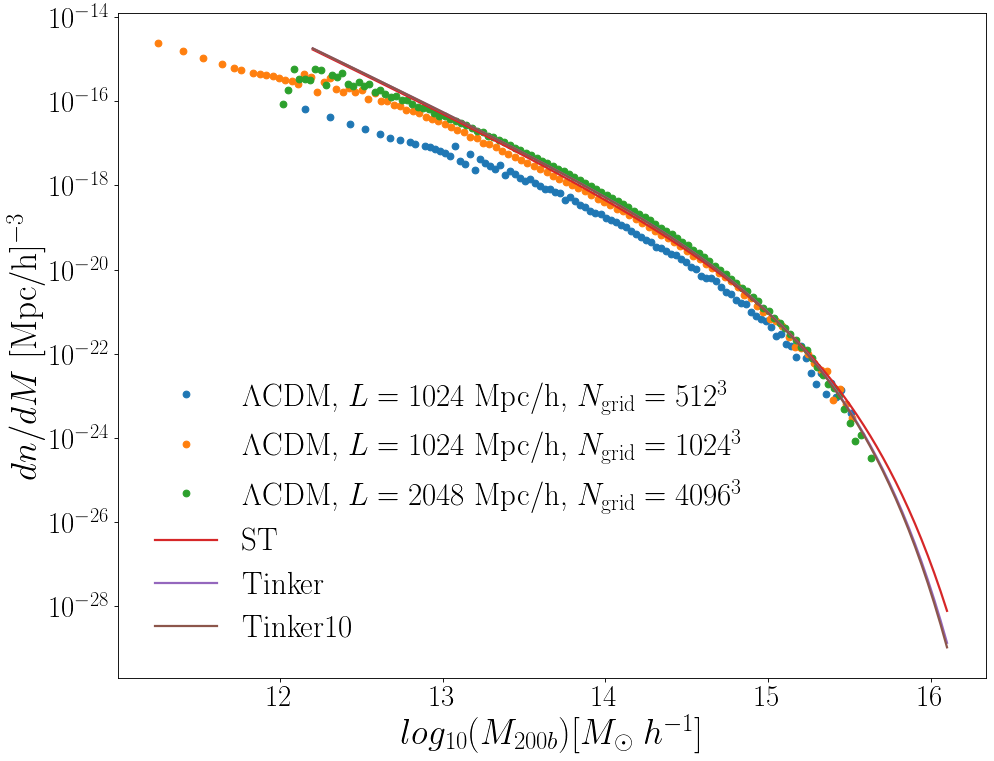

In [7]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096^3$")

for author in names:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# $M_{\rm vir}$

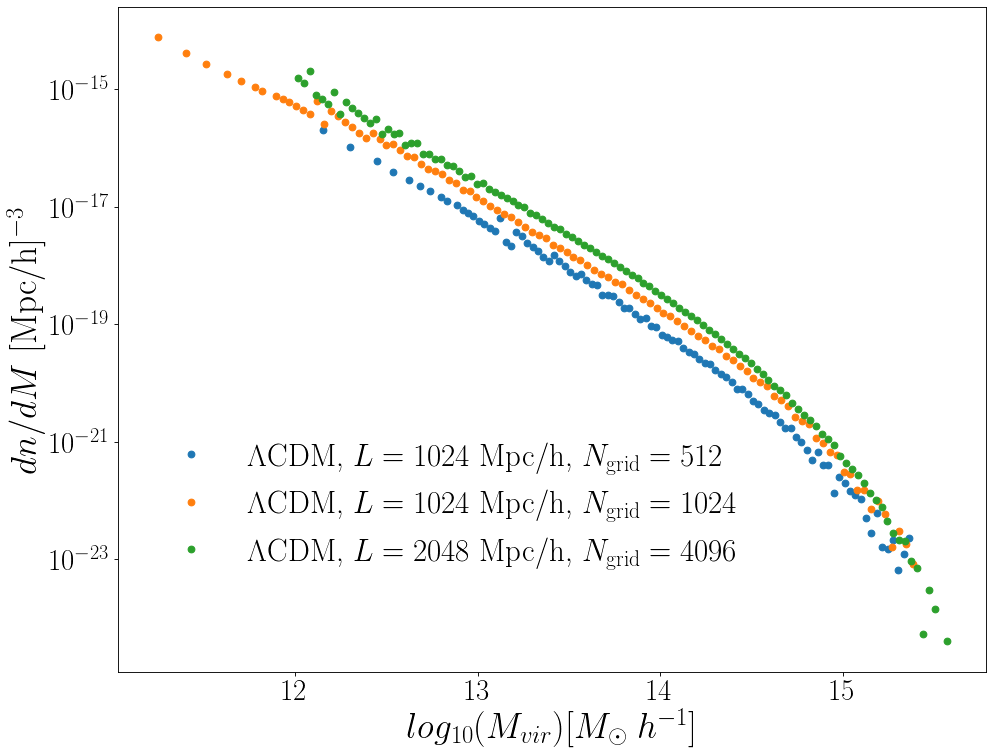

In [6]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096$")



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{vir}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

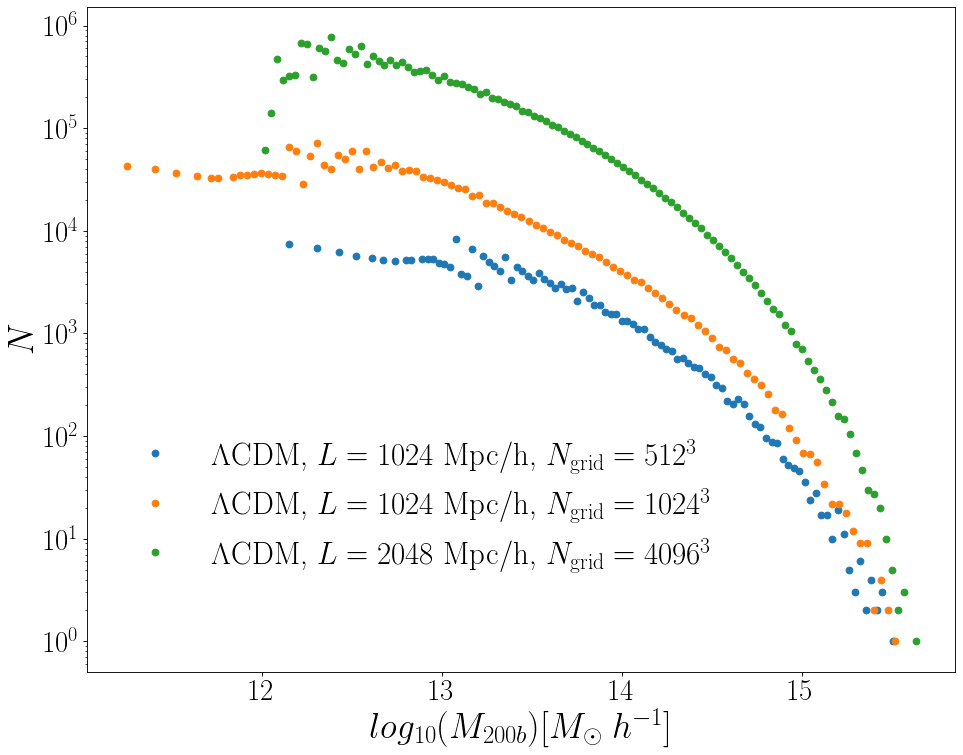

In [11]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096^3$")

# for author in names:
#     plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$N$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

## 0.3 eV

In [54]:
# sim_spec_s= "L_1024_Ngrid_512/"
# sim_spec_m= "L_1024_Ngrid_1024/"
# sim="0.3ev"
# sim_l="nu300meV"

# halos_catalogue_small = np.loadtxt("./../../simulations/"+sim_spec_s+sim+"/output/halos/out_2.list");
# halos_catalogue_medium =np.loadtxt("./../../simulations/"+sim_spec_m+"/simulations/"+sim+"/output/halos/out_2.list");
# halos_catalogue_large = np.loadtxt("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat");


In [8]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]

# nbins = 110;
# boxsize = 1024
# x=halos_catalogue_small[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=1024$ Mpc/h, $N_{\rm grid} = 512$")


# nbins = 110;
# boxsize = 1024
# x=halos_catalogue_medium[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=1024$ Mpc/h, $N_{\rm grid} = 1024$")


# nbins = 110;
# boxsize = 2048
# x=halos_catalogue_large[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=2048$ Mpc/h, $N_{\rm grid} = 4096$")



# plt.xlabel(r"$dx$ [Mpc/h]")
# plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
# plt.xlabel(r'$log_{10} M[ M_{\odot} \; h^{-1}$]',fontsize=32)
# plt.yscale('log')
# plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )